# Notebook 03 — Optimisation des Hyperparamètres avec Optuna

**Projet 4 — Auto-ML adaptatif : Recommandation dynamique de modèles**  
**Dataset : UNSW-NB15 (Détection d'intrusions réseau)**  
**École : EMSI Marrakech — 4ème année AIDATA**

---

## Objectif
Documenter l'optimisation bayésienne des hyperparamètres :
- `epsilon` : taux d'exploration du bandit
- `max_depth` : profondeur max du HoeffdingTree
- `n_neighbors` : nombre de voisins du KNN
- `delta` : sensibilité du détecteur ADWIN

## 1. Imports

In [19]:
import sys
import os
import json
sys.path.append(os.path.dirname(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

print('✓ Imports réussis')

✓ Imports réussis


## 2. Charger les Résultats Optuna

In [25]:
# Charger le JSON des résultats sauvegardé par optuna_tuning.py
chemin_json = '../data/logs/optuna_resultats.json'

with open(chemin_json, 'r', encoding='utf-8') as f:
    resultats = json.load(f)

print('=== Résultats Optuna chargés ===')
print(f'Meilleure précision : {resultats["meilleure_precision"]}')
print(f'Nombre de trials    : {resultats["nombre_trials"]}')
print(f'\nMeilleurs paramètres :')
for param, val in resultats['meilleurs_params'].items():
    print(f'  {param:<15} = {val}')

=== Résultats Optuna chargés ===
Meilleure précision : 1.0
Nombre de trials    : 30

Meilleurs paramètres :
  epsilon         = 0.011478343179876517
  max_depth       = 22
  n_neighbors     = 12
  delta           = 0.0035467336693774235


## 3. Visualisation des Trials

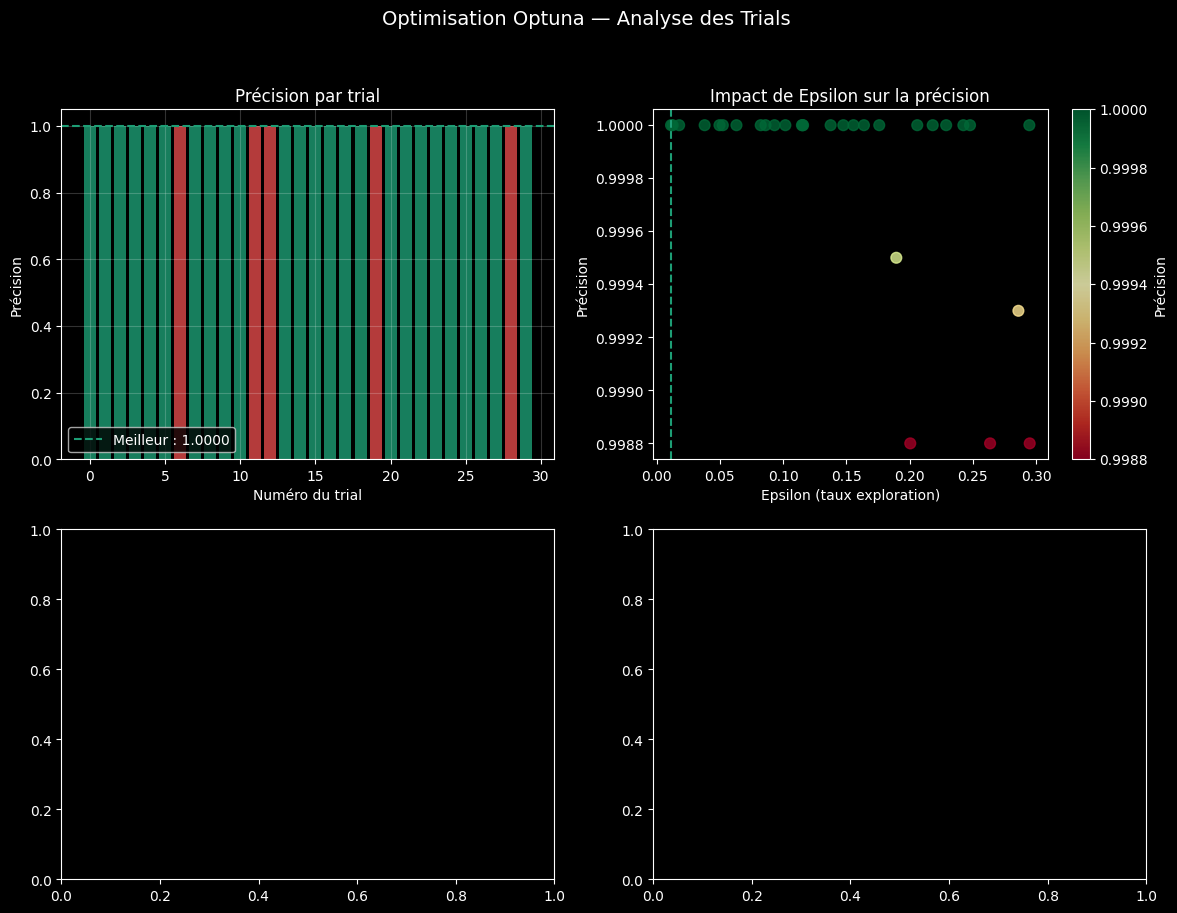

In [26]:
# Extraire les données de tous les trials
trial    = resultats.get('tous_les_trials', [])
numeros    = [t['trial'] for t in trial]
precisions = [t['precision'] for t in trial]
epsilons   = [t['params']['epsilon'] for t in trial]
max_depths = [t['params']['max_depth'] for t in trial]
n_neighbors= [t['params']['n_neighbors'] for t in trial]

if not precisions or not epsilons:
    print("Aucun résultat de trial disponible pour le graphique. Relancez l'optimisation Optuna pour générer les données de trials.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Optimisation Optuna — Analyse des Trials', fontsize=14)

    best_precision = max(precisions)
    couleurs = ['#E24B4A' if p < best_precision else '#1D9E75' for p in precisions]

    ax = axes[0, 0]
    ax.bar(numeros, precisions, color=couleurs, alpha=0.8)
    ax.axhline(y=best_precision, color='#1D9E75', linestyle='--', linewidth=1.5,
               label=f'Meilleur : {best_precision:.4f}')
    ax.set_xlabel('Numéro du trial')
    ax.set_ylabel('Précision')
    ax.set_title('Précision par trial')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

    ax = axes[0, 1]
    scatter = ax.scatter(epsilons, precisions, c=precisions,
                         cmap='RdYlGn', alpha=0.8, s=60)
    plt.colorbar(scatter, ax=ax, label='Précision')
    best_eps = resultats['meilleurs_params']['epsilon']
    ax.axvline(x=best_eps, color='#1D9E75', linestyle='--',
               label=f'Meilleur ε={best_eps:.3f}')
    ax.set_xlabel('Epsilon (taux exploration)')
    ax.set_ylabel('Précision')
    ax.set_title('Impact de Epsilon sur la précision')

## 4. Évolution de la Meilleure Précision

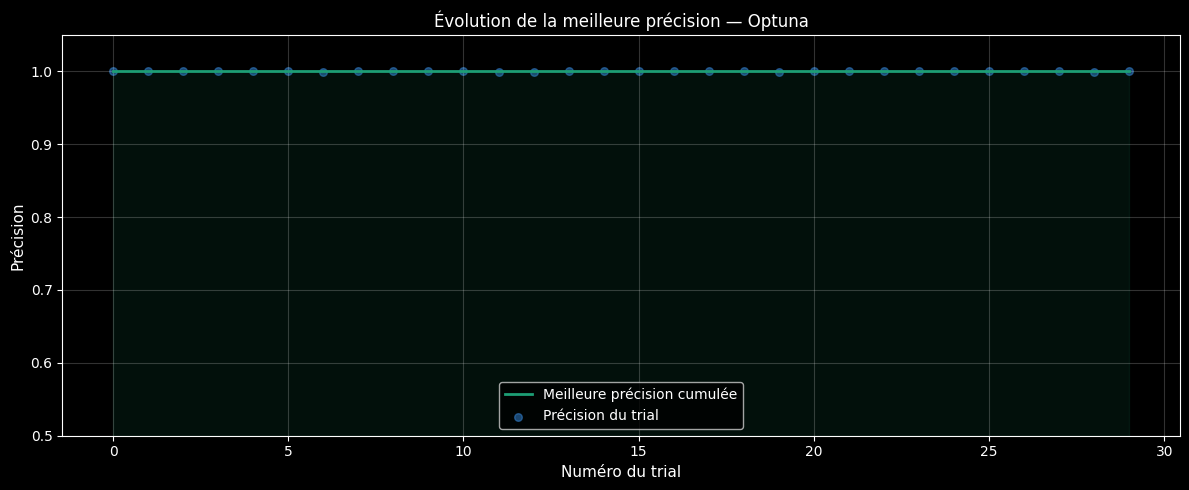

✓ Graphique de convergence sauvegardé


In [27]:
# Courbe de la meilleure précision cumulée
meilleure_cumul = []
best_so_far = 0
for p in precisions:
    if p > best_so_far:
        best_so_far = p
    meilleure_cumul.append(best_so_far)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(numeros, meilleure_cumul, color='#1D9E75', linewidth=2,
        label='Meilleure précision cumulée')
ax.scatter(numeros, precisions, color='#378ADD', alpha=0.5, s=30,
           label='Précision du trial')
ax.fill_between(numeros, meilleure_cumul, alpha=0.1, color='#1D9E75')
ax.set_xlabel('Numéro du trial', fontsize=11)
ax.set_ylabel('Précision', fontsize=11)
ax.set_title('Évolution de la meilleure précision — Optuna', fontsize=12)
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../data/logs/optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphique de convergence sauvegardé')

## 5. Tableau Récapitulatif

In [28]:
best = resultats['meilleurs_params']

print('=' * 55)
print('   RÉSUMÉ OPTIMISATION OPTUNA')
print('=' * 55)
print(f'  Algorithme       : Recherche bayésienne')
print(f'  Nombre de trials : {resultats["nombre_trials"]}')
print(f'  Exemples/trial   : 5 000')
print(f'  Meilleure préc.  : {resultats["meilleure_precision"]*100:.2f}%')
print()
print('  Meilleurs hyperparamètres :')
print(f'    epsilon     = {best["epsilon"]:.4f}  (taux exploration bandit)')
print(f'    max_depth   = {best["max_depth"]}       (profondeur HoeffdingTree)')
print(f'    n_neighbors = {best["n_neighbors"]}       (voisins KNN_ADWIN)')
print(f'    delta       = {best["delta"]:.4f}  (sensibilité ADWIN)')
print('=' * 55)
print('\n✓ Notebook 03 terminé — optimisation documentée')

   RÉSUMÉ OPTIMISATION OPTUNA
  Algorithme       : Recherche bayésienne
  Nombre de trials : 30
  Exemples/trial   : 5 000
  Meilleure préc.  : 100.00%

  Meilleurs hyperparamètres :
    epsilon     = 0.0115  (taux exploration bandit)
    max_depth   = 22       (profondeur HoeffdingTree)
    n_neighbors = 12       (voisins KNN_ADWIN)
    delta       = 0.0035  (sensibilité ADWIN)

✓ Notebook 03 terminé — optimisation documentée
